<center>
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-DV0101EN-SkillsNetwork/labs/Module%202/images/IDSNlogo.png" width="300" alt="cognitiveclass.ai logo">
</center>

# Plotting directly with Matplotlib

Estimated time needed: **45** minutes

## Objectives

After completing this lab you will be able to:

*   Create and customize basic plots directly with Matplotlib on dataset


# Import Libraries<a id="0"></a>


Import the `matplotlib` library.


In [11]:
#Import Primary Modules:
import numpy as np  # useful for many scientific computing in Python
import pandas as pd # primary data structure library

# use the inline backend to generate the plots within the browser
%matplotlib inline

import matplotlib as mpl
import matplotlib.pyplot as plt

# check for latest version of Matplotlib
print('Matplotlib version: ', mpl.__version__) # >= 2.0.0

Matplotlib version:  3.5.2


# Fetching Data<a id="1"></a>

Dataset: Immigration to Canada from 1980 to 2013 - [International migration flows to and from selected countries - The 2015 revision](https://www.un.org/development/desa/pd/data/international-migration-flows) from United Nation's website.<br>
In this lab, we will focus on the Canadian Immigration data and use the *already cleaned dataset* and can be fetched from <a href="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-DV0101EN-SkillsNetwork/Data%20Files/Canada.csv">here</a>.
<br><br>
You can refer to the lab on data pre-processing wherein this dataset is cleaned for a quick refresh your Panads skill [Data pre-processing with Pandas](https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-DV0101EN-SkillsNetwork/labs/june2023_updates/Module%201/DV0101EN-Exercise-Dataset-Preprocessing-Exploring-with-Pandas.ipynb)


In [12]:
from js import fetch
import io

URL = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-DV0101EN-SkillsNetwork/Data%20Files/Canada.csv"
resp = await fetch(URL)
text = io.BytesIO((await resp.arrayBuffer()).to_py())
df_can = pd.read_csv(text)
print('Data read into a pandas dataframe!')

Data read into a pandas dataframe!


Let's take a look at the first five items in our dataset.


In [13]:
df_can.head()

,Country,Continent,Region,DevName,1980,1981,1982,1983,1984,1985,...,2005,2006,2007,2008,2009,2010,2011,2012,2013,Total
0,Afghanistan,Asia,Southern Asia,Developing regions,16,39,39,47,71,340,...,3436,3009,2652,2111,1746,1758,2203,2635,2004,58639
1,Albania,Europe,Southern Europe,Developed regions,1,0,0,0,0,0,...,1223,856,702,560,716,561,539,620,603,15699
2,Algeria,Africa,Northern Africa,Developing regions,80,67,71,69,63,44,...,3626,4807,3623,4005,5393,4752,4325,3774,4331,69439
3,American Samoa,Oceania,Polynesia,Developing regions,0,1,0,0,0,0,...,0,1,0,0,0,0,0,0,0,6
4,Andorra,Europe,Southern Europe,Developed regions,0,0,0,0,0,0,...,0,1,1,0,0,0,0,1,1,15


Let's find out how many entries there are in our dataset.


In [14]:
# print the dimensions of the dataframe
print(df_can.shape)

(195, 39)


Set the country name as index - useful for quickly looking up countries using .loc method.


In [15]:
df_can.set_index('Country', inplace=True)

# Let's view the first five elements and see how the dataframe was changed
df_can.head()

,Continent,Region,DevName,1980,1981,1982,1983,1984,1985,1986,...,2005,2006,2007,2008,2009,2010,2011,2012,2013,Total
Country,,,,,,,,,,,,,,,,,,,,,
Afghanistan,Asia,Southern Asia,Developing regions,16,39,39,47,71,340,496,...,3436,3009,2652,2111,1746,1758,2203,2635,2004,58639
Albania,Europe,Southern Europe,Developed regions,1,0,0,0,0,0,1,...,1223,856,702,560,716,561,539,620,603,15699
Algeria,Africa,Northern Africa,Developing regions,80,67,71,69,63,44,69,...,3626,4807,3623,4005,5393,4752,4325,3774,4331,69439
American Samoa,Oceania,Polynesia,Developing regions,0,1,0,0,0,0,0,...,0,1,0,0,0,0,0,0,0,6
Andorra,Europe,Southern Europe,Developed regions,0,0,0,0,0,0,2,...,0,1,1,0,0,0,0,1,1,15


Notice now the country names now serve as indices.


In [16]:
print('data dimensions:', df_can.shape)

data dimensions: (195, 38)


In [17]:
# finally, let's create a list of years from 1980 - 2013
# this will come in handy when we start plotting the data
years = list(map(str, range(1980, 2014)))
#years = np.arange(1980,2014)

# Line Plots

Let's start with a case study:

In 2010, Haiti suffered a catastrophic magnitude 7.0 earthquake. The quake caused widespread devastation and loss of life and aout three million people were affected by this natural disaster. As part of Canada's humanitarian effort, the Government of Canada stepped up its effort in accepting refugees from Haiti. We can quickly visualize this effort using a Line plot:

### Question: Plot a line graph of immigration from Haiti 


You be required to create a dataframe where the name of the 'Country' is equal to 'Haiti' and years from 1980 - 2013<br> Also you will be required to transpose the new dataframe in to a series for plotting<br>Might also have to change the type of index of the series to integer for a better look of the plot<br> Then create fig and ax and call function plot() on the data.


Text(0, 0.5, 'Total immigrants')

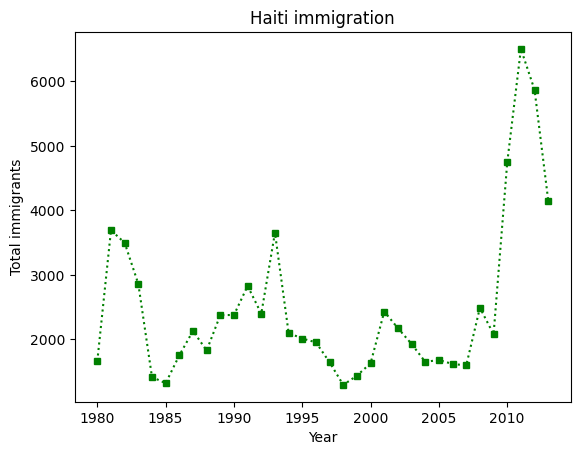

In [18]:
df_can.reset_index(inplace=True)
df_haiti = df_can[df_can['Country'] == 'Haiti']
haiti = df_haiti[years].T
haiti.index = map(int, haiti.index)

fig, ax = plt.subplots()
ax.plot(haiti, marker = 's', markersize = 5, color='green', linestyle='dotted')
ax.set_title('Haiti immigration')
ax.set_xlabel('Year')
ax.set_ylabel('Total immigrants')

# Bar Plots

### Question: Create a bar plot of the 5 countries that contributed the **least** to immigration to Canada **from** 1980 to 2013. 


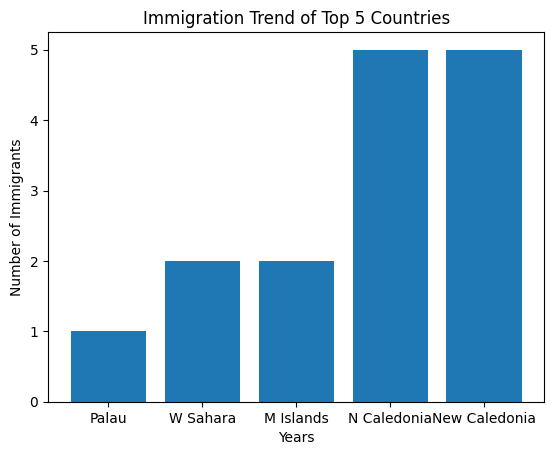

In [19]:
df_can.sort_values(['Total'], ascending=True, axis=0, inplace=True)
df_5least=df_can.head()
labels = list(df_5least['Country'])
labels[1] = 'W Sahara'
labels[2]='M Islands'
labels[3] = 'N Caledonia'
fig, ax =plt.subplots()
ax.bar(labels, df_5least['Total'], label = labels)

ax.set_title('Immigration Trend of Top 5 Countries')
ax.set_ylabel('Number of Immigrants')
ax.set_xlabel('Years')

plt.show()

#label =df_5least.Country

# Histograms

### Question: What is the immigration distribution for China and India for years 2000 to 2013?


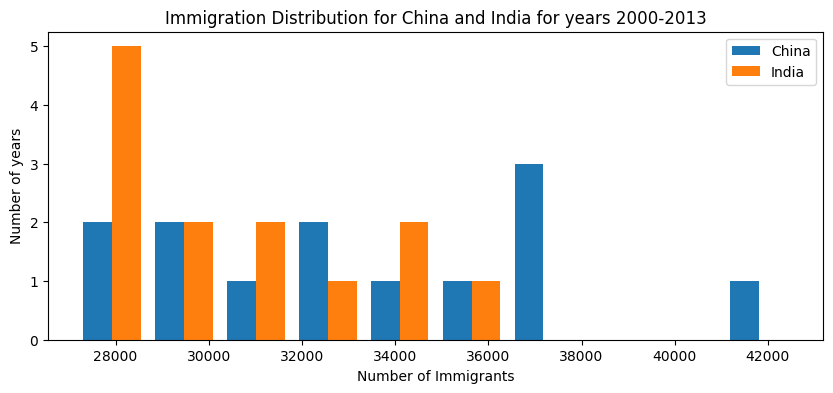

In [20]:
df = df_can.groupby(['Country'])[years].sum()
years_2000_2013 = list(map(str,range(2000,2013)))
df_CI =df.loc[['China','India'], years_2000_2013].T
df_CI.head()

fig,ax = plt.subplots(figsize=(10,4))
ax.hist(df_CI)
ax.set_xlabel('Number of Immigrants')
ax.set_ylabel('Number of years')
ax.set_title('Immigration Distribution for China and India for years 2000-2013')
plt.legend(['China','India'])

# Pie Chart<a id="14"></a>

A pie chart represents the proportion or percentage distribution of different categories in a dataset using sectors of a circular pie.
<br> Let's create a pie chart representing the 'Total Immigrants' for the year 1980 to 1985


### Question: Create a pie chart representing the total immigrants proportion for each continent

First, you will have to group the data over continents and get the sum on total. Then you can pass this data to the pie function


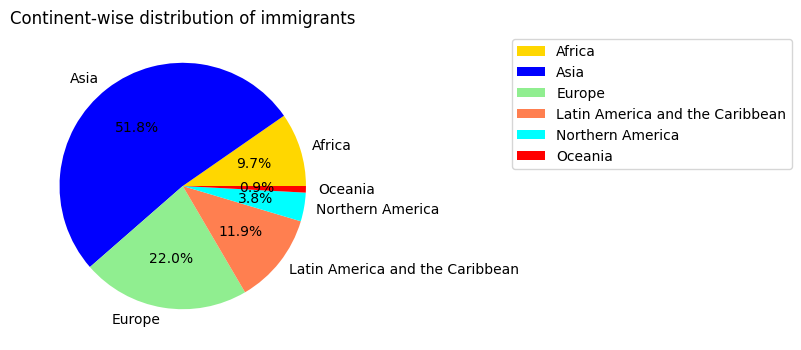

In [21]:
#Creating data for plotting pie
fig,ax=plt.subplots(figsize=(10, 4))
df_con = df_can.groupby('Continent')['Total'].sum().reset_index()

#Pie on immigrants
ax.pie(df_con['Total'], labels = df_con['Continent'],colors = ['gold','blue','lightgreen','coral','cyan','red'],
           autopct='%1.1f%%')

ax.set_aspect('equal') 

plt.title('Continent-wise distribution of immigrants')
ax.legend(df_con['Continent'],bbox_to_anchor=(2, 0, 0.5, 1))
plt.show()

# Subplots

### Question: Choose any four plots, which you have developed in this lab, with subplotting display them in a 2x2 display


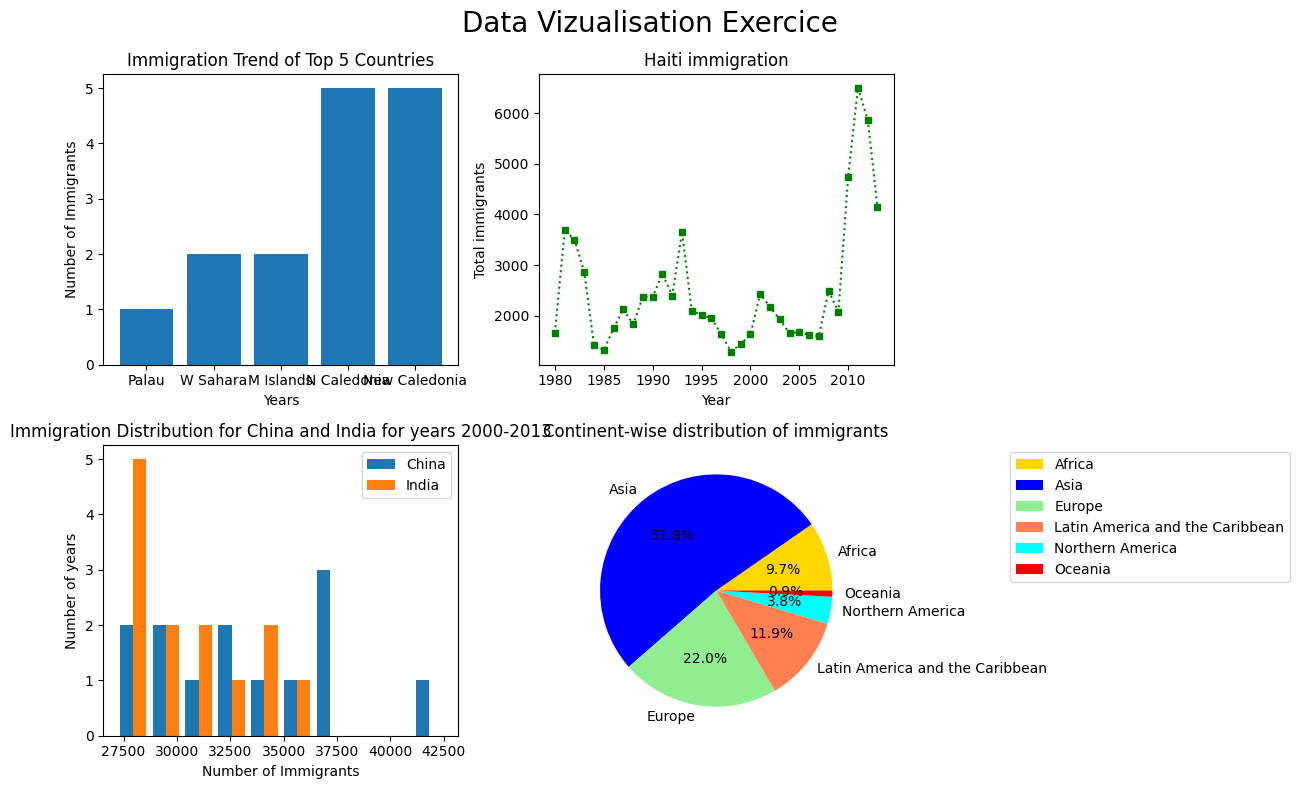

In [39]:
fig, ax = plt.subplots(2,2, figsize=(12,8))

ax[0,1].plot(haiti, marker = 's', markersize = 5, color='green', linestyle='dotted')
ax[0,1].set_title('Haiti immigration')
ax[0,1].set_xlabel('Year')
ax[0,1].set_ylabel('Total immigrants')

ax[0,0].bar(labels, df_5least['Total'], label = labels)
ax[0,0].set_title('Immigration Trend of Top 5 Countries')
ax[0,0].set_ylabel('Number of Immigrants')
ax[0,0].set_xlabel('Years')

ax[1,0].hist(df_CI)
ax[1,0].set_xlabel('Number of Immigrants')
ax[1,0].set_ylabel('Number of years')
ax[1,0].set_title('Immigration Distribution for China and India for years 2000-2013')
ax[1,0].legend(['China','India'])

ax[1,1].pie(df_con['Total'], labels = df_con['Continent'],colors = ['gold','blue','lightgreen','coral','cyan','red'], autopct='%1.1f%%')
ax[1,1].set_aspect('equal') 
ax[1,1].set_title('Continent-wise distribution of immigrants')
ax[1,1].legend(df_con['Continent'],bbox_to_anchor=(2, 0, 0.5, 1))


plt.suptitle('Data Vizualisation Exercice', fontsize=20)
fig.tight_layout()
plt.show()

---


### Congratulations! you have completed this lab!

## Author

[Dr. Pooja]()

### Other Contributors

## <h3 align="center"> © IBM Corporation 2020. All rights reserved. <h3/>



``` toggle## Change Log
```
``` toggle| Date (YYYY-MM-DD) | Version | Changed By    | Change Description                 |
```
``` toggle | ----------------- | ------- | ------------- | ---------------------------------- |
```
``` toggle | 2023-06-19        | 1.0     | Dr. Pooja        | initial version created   |
```


